# FAILSAFE — Model Training
### XGBoost + SMOTE + SHAP + Intervention Generator

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    f1_score
)
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

print("All imports done.")

All imports done.


## 2. Load Data

In [2]:
mat = pd.read_csv("data/student-mat.csv", sep=";")
por = pd.read_csv("data/student-por.csv", sep=";")

# add a column so we know which subject each row came from
mat["subject"] = "math"
por["subject"] = "por"

combined = pd.concat([mat, por], ignore_index=True)
combined.drop_duplicates(inplace=True)

print("Math rows       :", len(mat))
print("Portuguese rows :", len(por))
print("Combined rows   :", len(combined))
print("Columns         :", combined.shape[1])

Math rows       : 395
Portuguese rows : 649
Combined rows   : 1044
Columns         : 34


## 3. Create Target Variable

A student is **at-risk** if their final grade G3 < 10.

In [3]:
AT_RISK_THRESHOLD = 10

combined["at_risk"] = (combined["G3"] < AT_RISK_THRESHOLD).astype(int)

print("At-risk students :", combined["at_risk"].sum(), f"({combined['at_risk'].mean()*100:.1f}%)")
print("Safe students    :", (combined["at_risk"]==0).sum(), f"({(combined['at_risk']==0).mean()*100:.1f}%)")
print()
print("Note: students with G3=0 (likely dropouts) are included in at-risk")
print("G3=0 count:", (combined["G3"]==0).sum())

At-risk students : 230 (22.0%)
Safe students    : 814 (78.0%)

Note: students with G3=0 (likely dropouts) are included in at-risk
G3=0 count: 53


## 4. Feature Engineering

Creating 3 extra features that should help the model.

In [4]:
# total alcohol = workday + weekend
combined["total_alcohol"] = combined["Dalc"] + combined["Walc"]

# grade trend — is the student improving or declining?
combined["grade_trend"] = combined["G2"] - combined["G1"]

# how much grade output per unit of study effort
combined["study_efficiency"] = combined["G1"] / (combined["studytime"] + 1)

print("total_alcohol   — range:", combined["total_alcohol"].min(), "to", combined["total_alcohol"].max())
print("grade_trend     — mean :", round(combined["grade_trend"].mean(), 2))
print("study_efficiency— mean :", round(combined["study_efficiency"].mean(), 2))
print()
print("grade_trend > 0 means improving, < 0 means declining")
print("Improving students:", (combined["grade_trend"] > 0).sum())
print("Declining students:", (combined["grade_trend"] < 0).sum())

total_alcohol   — range: 2 to 10
grade_trend     — mean : 0.03
study_efficiency— mean : 4.01

grade_trend > 0 means improving, < 0 means declining
Improving students: 401
Declining students: 337


## 5. Encode Categorical Features

XGBoost needs numbers — convert all string columns using LabelEncoder.

In [6]:
categorical_cols = [
    "sex", "address", "famsize", "Pstatus", "Mjob", "Fjob",
    "reason", "guardian", "schoolsup", "famsup", "paid",
    "activities", "nursery", "higher", "internet", "romantic"
]

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col].astype(str))
    label_encoders[col] = le
    print(f"{col:12s} → {dict(zip(le.classes_, le.transform(le.classes_)))}")

joblib.dump(label_encoders, "ml_pipeline/label_encoders.pkl")
print("\nSaved label_encoders.pkl")

sex          → {'0': np.int64(0), '1': np.int64(1)}
address      → {'0': np.int64(0), '1': np.int64(1)}
famsize      → {'0': np.int64(0), '1': np.int64(1)}
Pstatus      → {'0': np.int64(0), '1': np.int64(1)}
Mjob         → {'0': np.int64(0), '1': np.int64(1), '2': np.int64(2), '3': np.int64(3), '4': np.int64(4)}
Fjob         → {'0': np.int64(0), '1': np.int64(1), '2': np.int64(2), '3': np.int64(3), '4': np.int64(4)}
reason       → {'0': np.int64(0), '1': np.int64(1), '2': np.int64(2), '3': np.int64(3)}
guardian     → {'0': np.int64(0), '1': np.int64(1), '2': np.int64(2)}
schoolsup    → {'0': np.int64(0), '1': np.int64(1)}
famsup       → {'0': np.int64(0), '1': np.int64(1)}
paid         → {'0': np.int64(0), '1': np.int64(1)}
activities   → {'0': np.int64(0), '1': np.int64(1)}
nursery      → {'0': np.int64(0), '1': np.int64(1)}
higher       → {'0': np.int64(0), '1': np.int64(1)}
internet     → {'0': np.int64(0), '1': np.int64(1)}
romantic     → {'0': np.int64(0), '1': np.int64(1)}

Saved

## 6. Define Feature Set

We use G1 and G2 (valid mid-semester signals). We do NOT use G3 — that's our target.

In [7]:
FEATURES = [
    "age", "sex", "address", "famsize", "Pstatus",
    "Medu", "Fedu", "Mjob", "Fjob", "reason", "guardian",
    "traveltime", "studytime", "failures",
    "schoolsup", "famsup", "paid", "activities", "nursery",
    "higher", "internet", "romantic",
    "famrel", "freetime", "goout",
    "Dalc", "Walc", "health", "absences",
    "G1", "G2",
    "total_alcohol", "grade_trend", "study_efficiency"
]

X = combined[FEATURES]
y = combined["at_risk"]

joblib.dump(FEATURES, "ml_pipeline/feature_columns.pkl")

print("Total features :", len(FEATURES))
print("Total samples  :", len(X))
print()
print("Feature list:")
for i, f in enumerate(FEATURES):
    print(f"  {i+1:2d}. {f}")

Total features : 34
Total samples  : 1044

Feature list:
   1. age
   2. sex
   3. address
   4. famsize
   5. Pstatus
   6. Medu
   7. Fedu
   8. Mjob
   9. Fjob
  10. reason
  11. guardian
  12. traveltime
  13. studytime
  14. failures
  15. schoolsup
  16. famsup
  17. paid
  18. activities
  19. nursery
  20. higher
  21. internet
  22. romantic
  23. famrel
  24. freetime
  25. goout
  26. Dalc
  27. Walc
  28. health
  29. absences
  30. G1
  31. G2
  32. total_alcohol
  33. grade_trend
  34. study_efficiency


## 7. Train / Test Split

Using 80/20 split with stratify to keep class ratio balanced in both sets.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train), "| At-risk in train:", y_train.sum())
print("Test size :", len(X_test),  "| At-risk in test :", y_test.sum())
print()
print("Train at-risk rate:", round(y_train.mean()*100, 1), "%")
print("Test  at-risk rate:", round(y_test.mean()*100, 1), "%")

Train size: 835 | At-risk in train: 184
Test size : 209 | At-risk in test : 46

Train at-risk rate: 22.0 %
Test  at-risk rate: 22.0 %


## 8. Handle Class Imbalance with SMOTE

SMOTE creates synthetic samples of the minority class so the model doesn't get biased towards predicting 'safe' all the time.

In [9]:
print("Before SMOTE:")
print("  Class 0 (safe)    :", (y_train==0).sum())
print("  Class 1 (at-risk) :", (y_train==1).sum())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print("  Class 0 (safe)    :", (y_train_res==0).sum())
print("  Class 1 (at-risk) :", (y_train_res==1).sum())
print("  Total training samples:", len(X_train_res))

Before SMOTE:
  Class 0 (safe)    : 651
  Class 1 (at-risk) : 184

After SMOTE:
  Class 0 (safe)    : 651
  Class 1 (at-risk) : 651
  Total training samples: 1302


## 9. Baseline Model

Before training XGBoost, let's see what a dumb model that always predicts the majority class scores. This is the floor we need to beat.

In [10]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train_res, y_train_res)
y_pred_base = baseline.predict(X_test)

print("Baseline (always predicts majority class):")
print(classification_report(y_test, y_pred_base, target_names=["Safe", "At-Risk"]))
print("This is our floor. Any real model must do better than this.")

Baseline (always predicts majority class):
              precision    recall  f1-score   support

        Safe       0.78      1.00      0.88       163
     At-Risk       0.00      0.00      0.00        46

    accuracy                           0.78       209
   macro avg       0.39      0.50      0.44       209
weighted avg       0.61      0.78      0.68       209

This is our floor. Any real model must do better than this.


## 10. Train XGBoost Model

In [11]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("Model training complete.")
print("Number of trees built:", model.n_estimators)

Model training complete.
Number of trees built: 300


## 11. Cross Validation (5-Fold)

Checking that the model generalises and isn't just memorising the training data.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'Metric':<12} {'Mean':>8} {'Std':>8}  Fold scores")
print("-" * 65)

for metric in ["f1", "roc_auc", "precision", "recall"]:
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=metric, n_jobs=-1)
    fold_str = "  ".join([str(round(s, 3)) for s in scores])
    print(f"{metric:<12} {scores.mean():>8.3f} {scores.std():>8.3f}  [{fold_str}]")

Metric           Mean      Std  Fold scores
-----------------------------------------------------------------
f1              0.787    0.042  [0.849  0.757  0.769  0.822  0.735]
roc_auc         0.957    0.016  [0.974  0.969  0.956  0.956  0.929]
precision       0.793    0.042  [0.838  0.757  0.732  0.833  0.806]
recall          0.783    0.063  [0.861  0.757  0.811  0.811  0.676]


## 12. Test Set Evaluation

In [13]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Safe", "At-Risk"]))

print(f"ROC-AUC Score       : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Avg Precision Score : {average_precision_score(y_test, y_prob):.4f}")

Classification Report:
              precision    recall  f1-score   support

        Safe       0.95      0.91      0.93       163
     At-Risk       0.72      0.83      0.77        46

    accuracy                           0.89       209
   macro avg       0.83      0.87      0.85       209
weighted avg       0.90      0.89      0.89       209

ROC-AUC Score       : 0.9644
Avg Precision Score : 0.9008


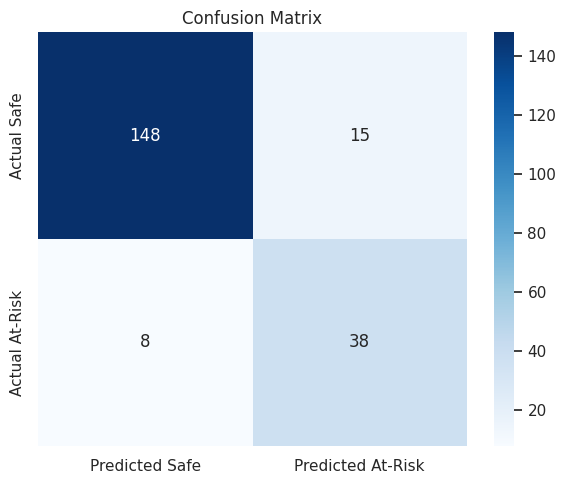

True Positives  (at-risk correctly caught) : 38
False Negatives (at-risk missed)           : 8  ← most costly mistake
False Positives (safe flagged incorrectly) : 15
True Negatives  (safe correctly cleared)   : 148

Recall (% of at-risk students caught) : 82.6%
Precision (% of flags that are correct): 71.7%


In [14]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Safe", "Predicted At-Risk"],
            yticklabels=["Actual Safe", "Actual At-Risk"])
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print(f"True Positives  (at-risk correctly caught) : {tp}")
print(f"False Negatives (at-risk missed)           : {fn}  ← most costly mistake")
print(f"False Positives (safe flagged incorrectly) : {fp}")
print(f"True Negatives  (safe correctly cleared)   : {tn}")
print()
print(f"Recall (% of at-risk students caught) : {tp/(tp+fn)*100:.1f}%")
print(f"Precision (% of flags that are correct): {tp/(tp+fp)*100:.1f}%")

## 13. ROC Curve and Precision-Recall Curve

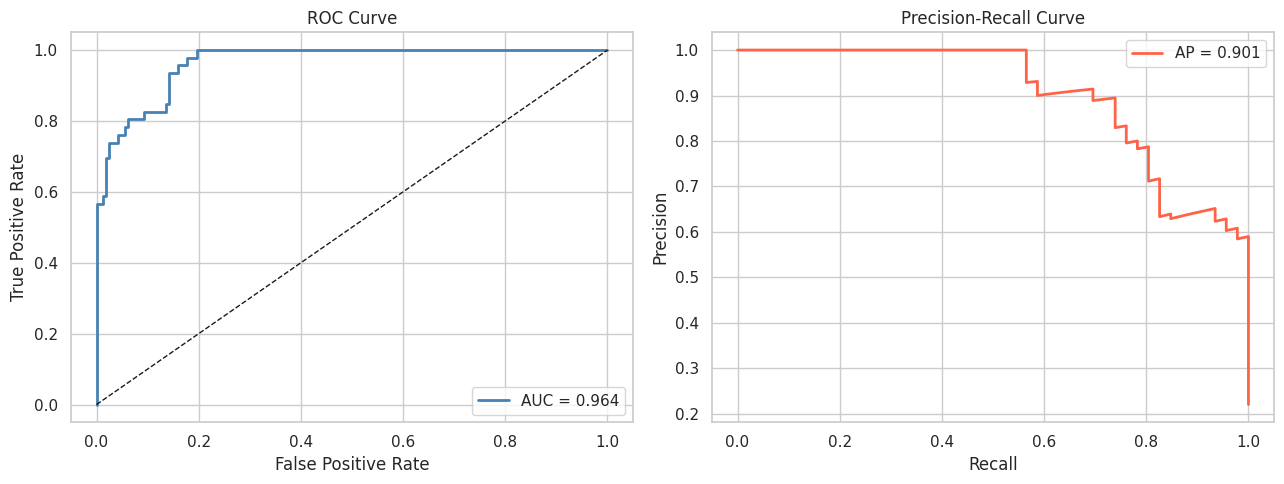

In [15]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

precision_arr, recall_arr, _ = precision_recall_curve(y_test, y_prob)
avg_prec = average_precision_score(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr, tpr, color="steelblue", linewidth=2, label=f"AUC = {auc:.3f}")
axes[0].plot([0,1], [0,1], "k--", linewidth=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

# Precision-Recall
axes[1].plot(recall_arr, precision_arr, color="tomato", linewidth=2, label=f"AP = {avg_prec:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

## 14. Threshold Tuning

Default threshold is 0.5. For a school system we want high recall — better to flag an extra student than to miss one who's failing.

In [16]:
print(f"{'Threshold':>10}  {'Precision':>10}  {'Recall':>10}  {'F1':>8}  {'Flagged':>8}")
print("-" * 55)

best_f1 = 0
best_thresh = 0.5

for thresh in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    y_t = (y_prob >= thresh).astype(int)
    prec = tp_count = (y_t[y_test==1]==1).sum()
    tp_t = (y_t[y_test==1]==1).sum()
    fp_t = (y_t[y_test==0]==1).sum()
    fn_t = (y_t[y_test==1]==0).sum()
    prec_t = tp_t / max(tp_t + fp_t, 1)
    rec_t  = tp_t / max(tp_t + fn_t, 1)
    f1_t   = 2 * prec_t * rec_t / max(prec_t + rec_t, 1e-9)
    flagged = y_t.sum()
    marker = " ← best F1" if f1_t > best_f1 else ""
    print(f"{thresh:>10.2f}  {prec_t:>10.3f}  {rec_t:>10.3f}  {f1_t:>8.3f}  {flagged:>8}{marker}")
    if f1_t > best_f1:
        best_f1 = f1_t
        best_thresh = thresh

print()
print(f"Recommended threshold for schools: 0.40 (higher recall, catch more at-risk students)")
print(f"Best F1 threshold: {best_thresh}")

 Threshold   Precision      Recall        F1   Flagged
-------------------------------------------------------
      0.30       0.633       0.826     0.717        60 ← best F1
      0.35       0.655       0.826     0.731        58 ← best F1
      0.40       0.667       0.826     0.738        57 ← best F1
      0.45       0.691       0.826     0.752        55 ← best F1
      0.50       0.717       0.826     0.768        53 ← best F1
      0.55       0.725       0.804     0.763        51
      0.60       0.740       0.804     0.771        50 ← best F1

Recommended threshold for schools: 0.40 (higher recall, catch more at-risk students)
Best F1 threshold: 0.6


## 15. Feature Importance (XGBoost Gain)

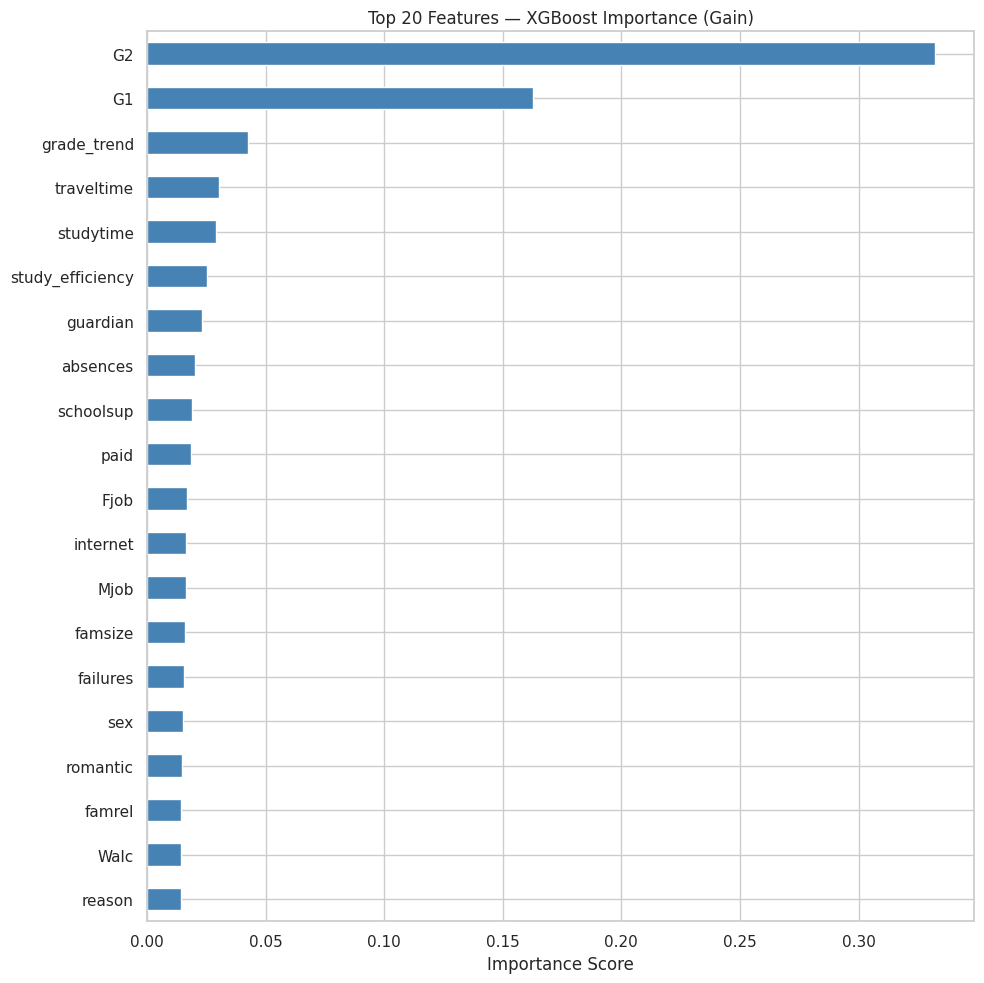

Top 10 most important features:
  G2                  : 0.3321
  G1                  : 0.1627
  grade_trend         : 0.0428
  traveltime          : 0.0304
  studytime           : 0.0291
  study_efficiency    : 0.0252
  guardian            : 0.0232
  absences            : 0.0202
  schoolsup           : 0.0188
  paid                : 0.0184


In [17]:
importance = pd.Series(model.feature_importances_, index=FEATURES)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(10, 10))
importance.tail(20).plot(kind="barh", color="steelblue", edgecolor="white")
plt.title("Top 20 Features — XGBoost Importance (Gain)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
for feat, val in importance.sort_values(ascending=False).head(10).items():
    print(f"  {feat:20s}: {val:.4f}")

## 16. SHAP — Global Feature Importance

SHAP tells us not just which features matter, but HOW they push the prediction up or down.

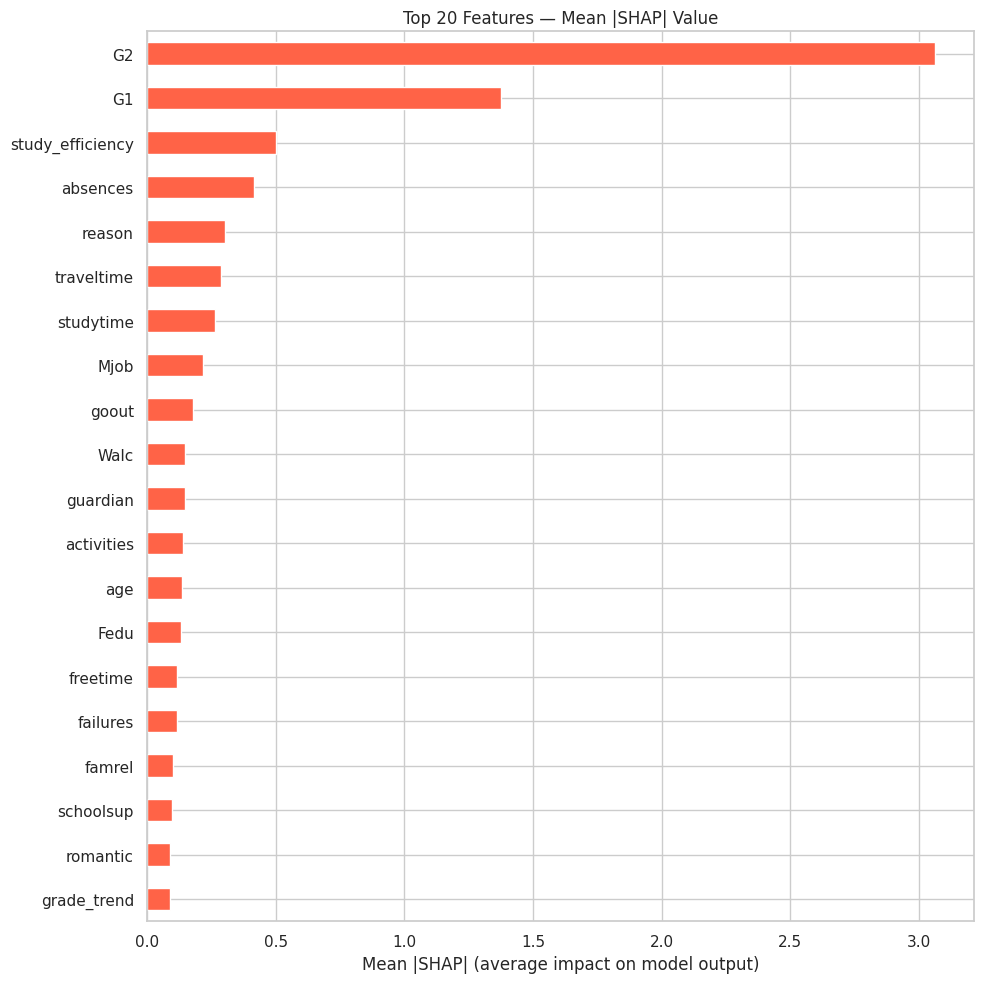

Top 10 features by mean |SHAP|:
  G2                  : 3.0607
  G1                  : 1.3757
  study_efficiency    : 0.5009
  absences            : 0.4158
  reason              : 0.3029
  traveltime          : 0.2873
  studytime           : 0.2625
  Mjob                : 0.2162
  goout               : 0.1788
  Walc                : 0.1475


In [18]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# mean absolute SHAP per feature
mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURES)
mean_shap = mean_shap.sort_values(ascending=True)

plt.figure(figsize=(10, 10))
mean_shap.tail(20).plot(kind="barh", color="tomato", edgecolor="white")
plt.title("Top 20 Features — Mean |SHAP| Value")
plt.xlabel("Mean |SHAP| (average impact on model output)")
plt.tight_layout()
plt.show()

print("Top 10 features by mean |SHAP|:")
for feat, val in mean_shap.sort_values(ascending=False).head(10).items():
    print(f"  {feat:20s}: {val:.4f}")

## 17. SHAP Summary Plot

Red = high feature value, Blue = low feature value. Right side = pushes toward at-risk.

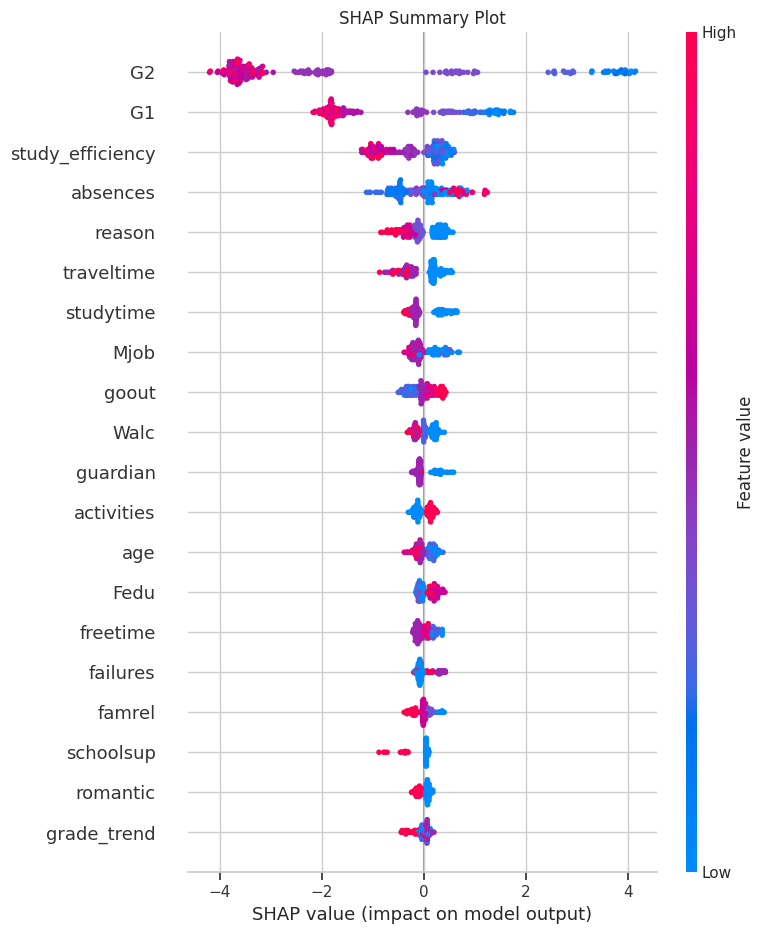

In [19]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False, max_display=20)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

## 18. SHAP — Individual Student Explanation

This is what faculty will see: exactly WHY a student was flagged.

In [20]:
# pick one at-risk student and one safe student from test set
at_risk_idx = X_test[y_test == 1].index[0]
safe_idx    = X_test[y_test == 0].index[0]

for label, idx in [("AT-RISK", at_risk_idx), ("SAFE", safe_idx)]:
    prob = model.predict_proba(X_test.loc[[idx]])[0][1]
    shap_row = shap_values[X_test.index.get_loc(idx)]

    factors = sorted(zip(FEATURES, shap_row), key=lambda x: abs(x[1]), reverse=True)

    print(f"Student — Predicted: {label} | Risk probability: {prob*100:.1f}%")
    print(f"{'Feature':<22} {'SHAP Value':>12}  Direction")
    print("-" * 52)
    for feat, sv in factors[:8]:
        direction = "↑ increases risk" if sv > 0 else "↓ reduces risk"
        print(f"  {feat:<20} {sv:>10.4f}  {direction}")
    print()

Student — Predicted: AT-RISK | Risk probability: 99.3%
Feature                  SHAP Value  Direction
----------------------------------------------------
  G2                       3.9460  ↑ increases risk
  G1                       1.1159  ↑ increases risk
  reason                  -0.5891  ↓ reduces risk
  Mjob                     0.3641  ↑ increases risk
  absences                -0.3296  ↓ reduces risk
  study_efficiency         0.2920  ↑ increases risk
  traveltime               0.2886  ↑ increases risk
  Fedu                     0.2632  ↑ increases risk

Student — Predicted: SAFE | Risk probability: 0.1%
Feature                  SHAP Value  Direction
----------------------------------------------------
  G2                      -3.2708  ↓ reduces risk
  G1                      -1.4399  ↓ reduces risk
  study_efficiency        -1.1705  ↓ reduces risk
  traveltime              -0.3790  ↓ reduces risk
  studytime                0.2835  ↑ increases risk
  absences                -0.

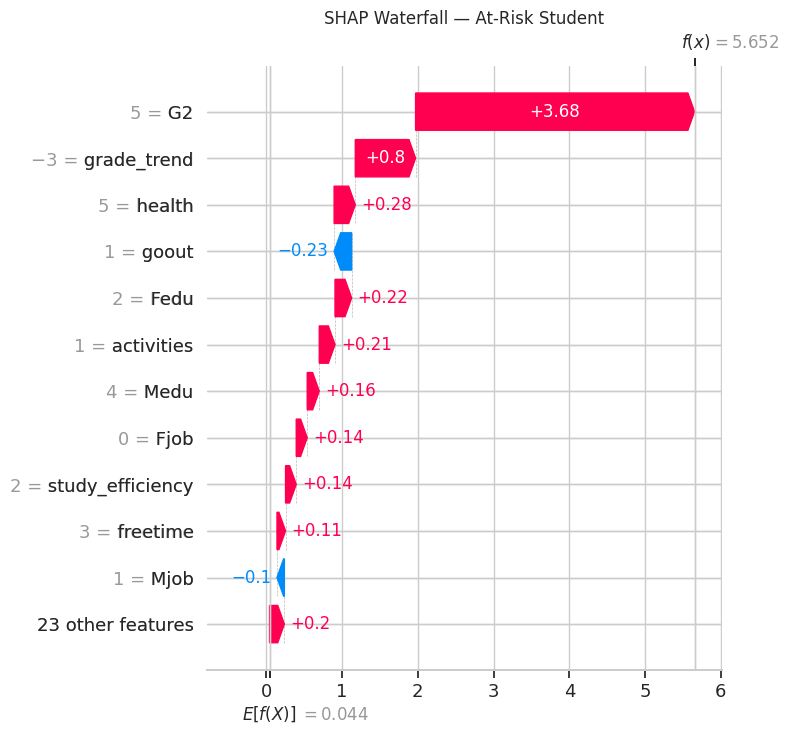

In [20]:
# waterfall plot for one at-risk student
idx = X_test[y_test == 1].index[0]
pos = X_test.index.get_loc(idx)

shap_exp = shap.Explanation(
    values=shap_values[pos],
    base_values=explainer.expected_value,
    data=X_test.iloc[pos].values,
    feature_names=FEATURES
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp, max_display=12, show=False)
plt.title("SHAP Waterfall — At-Risk Student")
plt.tight_layout()
plt.show()

## 19. Auto-Generate Intervention Plan

Once we have SHAP top factors, we map them to real actions for faculty.

In [21]:
INTERVENTIONS = {
    "absences":        ("Attendance counselling", "Student has high absences. Schedule a one-on-one attendance review and set weekly check-ins."),
    "failures":        ("Remedial support",       "Past failures indicate knowledge gaps. Enroll in remedial class and assign a peer mentor."),
    "G1":              ("Early academic support", "Low first-period grade. Review foundational concepts and schedule extra practice sessions."),
    "G2":              ("Urgent academic support","Mid-term grade is critically low. Immediate tutoring required. Inform HOD."),
    "grade_trend":     ("Arrest grade decline",   "Grades are declining semester over semester. Create a structured weekly study plan."),
    "studytime":       ("Study time intervention","Student studies less than 2 hours per week. Issue a personalised study timetable."),
    "study_efficiency":("Study skills workshop",  "Low grade output relative to study hours. Refer to a study skills or learning strategy workshop."),
    "Dalc":            ("Wellness referral",       "Elevated weekday alcohol use detected. Confidential referral to student wellness centre."),
    "Walc":            ("Wellness check-in",       "Weekend alcohol use is high. Private welfare conversation and optional wellness referral."),
    "total_alcohol":   ("Wellness referral",       "Overall alcohol consumption is high. Coordinate with student wellness team."),
    "goout":           ("Time management session", "High social time may be crowding out study time. Time management counselling recommended."),
    "famrel":          ("Pastoral care",           "Poor family relationships reported. Refer to pastoral care or counselling services."),
    "health":          ("Health check",            "Poor health status. Encourage a campus health check and review academic workload."),
    "internet":        ("Resource support",        "No internet at home. Arrange library access card and provide offline revision materials."),
    "famsup":          ("Faculty mentorship",      "No family academic support. Assign faculty mentor and schedule bi-weekly check-ins."),
    "higher":          ("Motivation counselling",  "Student not interested in higher education. Career counselling session recommended."),
    "Medu":            ("Additional resources",    "Low parental education background. Provide extra resource guides and support sessions."),
    "Fedu":            ("Additional resources",    "Low parental education background. Provide extra resource guides and support sessions."),
    "romantic":        ("Work-life balance talk",  "Romantic relationship may be affecting focus. Supportive conversation about balance."),
    "traveltime":      ("Transport support",       "Long commute causing fatigue. Explore hostel availability or transport subsidy."),
}

def generate_intervention_plan(student_row, model, explainer, feature_cols):
    prob = model.predict_proba(pd.DataFrame([student_row]))[0][1]
    shap_vals = explainer.shap_values(pd.DataFrame([student_row]))[0]

    factors = sorted(zip(feature_cols, shap_vals), key=lambda x: abs(x[1]), reverse=True)
    risk_factors = [(f, v) for f, v in factors if v > 0]  # only things pushing risk up

    urgency = "HIGH" if prob > 0.75 else "MEDIUM" if prob > 0.5 else "LOW"

    print(f"Risk Probability : {prob*100:.1f}%")
    print(f"Urgency Level    : {urgency}")
    print()
    print("Recommended Interventions:")
    print("-" * 55)

    count = 0
    for feat, sv in risk_factors[:5]:
        if feat in INTERVENTIONS:
            title, desc = INTERVENTIONS[feat]
            count += 1
            print(f"{count}. [{feat}] {title}")
            print(f"   {desc}")
            print()

    if count == 0:
        print("No specific interventions needed — student appears stable.")

# test it on a sample student
sample = X_test.iloc[0].to_dict()
generate_intervention_plan(sample, model, explainer, FEATURES)

Risk Probability : 99.3%
Urgency Level    : HIGH

Recommended Interventions:
-------------------------------------------------------
1. [G2] Urgent academic support
   Mid-term grade is critically low. Immediate tutoring required. Inform HOD.

2. [G1] Early academic support
   Low first-period grade. Review foundational concepts and schedule extra practice sessions.

3. [study_efficiency] Study skills workshop
   Low grade output relative to study hours. Refer to a study skills or learning strategy workshop.

4. [traveltime] Transport support
   Long commute causing fatigue. Explore hostel availability or transport subsidy.



## 20. Save Model Artifacts

In [22]:
joblib.dump(model,     "ml_pipeline/model.pkl")
joblib.dump(explainer, "ml_pipeline/explainer.pkl")
joblib.dump({
    "threshold": 0.40,
    "features": FEATURES,
    "at_risk_threshold": AT_RISK_THRESHOLD
}, "ml_pipeline/config.pkl")

print("Saved files:")
print("  ml_pipeline/model.pkl          — trained XGBoost model")
print("  ml_pipeline/explainer.pkl      — SHAP TreeExplainer")
print("  ml_pipeline/label_encoders.pkl — LabelEncoders for categorical columns")
print("  ml_pipeline/feature_columns.pkl— ordered feature list")
print("  ml_pipeline/config.pkl         — threshold + metadata")
print()
print("These files are loaded by the FastAPI backend at startup.")

Saved files:
  ml_pipeline/model.pkl          — trained XGBoost model
  ml_pipeline/explainer.pkl      — SHAP TreeExplainer
  ml_pipeline/label_encoders.pkl — LabelEncoders for categorical columns
  ml_pipeline/feature_columns.pkl— ordered feature list
  ml_pipeline/config.pkl         — threshold + metadata

These files are loaded by the FastAPI backend at startup.


## 21. Quick Sanity Check — Predict on a New Student

Simulate what the backend will do when faculty uploads a CSV.

In [23]:
# simulate a new student row (the kind that comes from a CSV upload)
new_student = {
    "age": 17, "sex": 1, "address": 1, "famsize": 0, "Pstatus": 1,
    "Medu": 2, "Fedu": 2, "Mjob": 2, "Fjob": 2, "reason": 3, "guardian": 1,
    "traveltime": 1, "studytime": 1, "failures": 2,
    "schoolsup": 0, "famsup": 0, "paid": 0, "activities": 0, "nursery": 1,
    "higher": 0, "internet": 1, "romantic": 0,
    "famrel": 2, "freetime": 4, "goout": 4,
    "Dalc": 3, "Walc": 4, "health": 2, "absences": 14,
    "G1": 5, "G2": 4,
    "total_alcohol": 7, "grade_trend": -1, "study_efficiency": 1.67
}

df_new = pd.DataFrame([new_student])[FEATURES]
prob = model.predict_proba(df_new)[0][1]
prediction = "AT-RISK" if prob >= 0.40 else "SAFE"

print(f"Prediction       : {prediction}")
print(f"Risk Probability : {prob*100:.1f}%")
print()

# SHAP explanation
shap_row = explainer.shap_values(df_new)[0]
factors = sorted(zip(FEATURES, shap_row), key=lambda x: abs(x[1]), reverse=True)
print("Top 5 risk factors:")
for feat, sv in factors[:5]:
    direction = "increases risk" if sv > 0 else "reduces risk"
    print(f"  {feat:22s}: {sv:+.4f}  ({direction})")

Prediction       : AT-RISK
Risk Probability : 99.5%

Top 5 risk factors:
  G2                    : +3.5363  (increases risk)
  G1                    : +1.4326  (increases risk)
  reason                : -0.6838  (reduces risk)
  absences              : +0.5638  (increases risk)
  studytime             : +0.4675  (increases risk)


## Done!

All artifacts saved. Next step: plug `ml_pipeline/model.pkl`, `explainer.pkl`, and `label_encoders.pkl` into the FastAPI backend.